In [1]:
# Setup and reusable plotting function

from pathlib import Path
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import norm

# Colours used in the Session 4 lecture notes.
NAVY = "#17365D"
BLUE = "#2D75A3"
LIGHT_BLUE = "#7CC4D0"
ORANGE = "#C96B16"
AXIS = "#263746"

# Save beside this notebook whether it is launched here or from the repository root.
search_folders = (Path.cwd(), *Path.cwd().parents)
OUTPUT_DIR = next(
    (folder / "04_Continuous_Distributions_in_Practice" / "session_material"
     for folder in search_folders
     if (folder / "04_Continuous_Distributions_in_Practice" / "session_material").exists()),
    Path.cwd(),
)
if Path.cwd().name == "session_material":
    OUTPUT_DIR = Path.cwd()

def compare_normal_distributions(distributions, filename, x_min=-4, x_max=4):
    """Plot normal PDFs on transparent backgrounds and save a transparent PNG."""
    x = np.linspace(x_min, x_max, 1200)
    fig, ax = plt.subplots(figsize=(8, 4.8))

    # Transparent figure and axes; dark text remains visible on a white page.
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    for mu, sigma, color in distributions:
        ax.plot(x, norm.pdf(x, loc=mu, scale=sigma), color=color, linewidth=3.0)

    ax.set(xlabel="$x$", ylabel="Density", xlim=(x_min, x_max), ylim=(0, None))
    ax.margins(x=0, y=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.spines["left"].set_color(AXIS)
    ax.tick_params(colors=AXIS, labelsize=11)
    ax.xaxis.label.set_color(AXIS)
    ax.yaxis.label.set_color(AXIS)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    fig.tight_layout()

    save_path = OUTPUT_DIR / filename
    fig.savefig(save_path, dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.03)
    print(f"Saved: {save_path}")
    plt.show()


Saved: C:\GitHub\STA1_26\04_Continuous_Distributions_in_Practice\session_material\normal_same_mean_different_variance.png


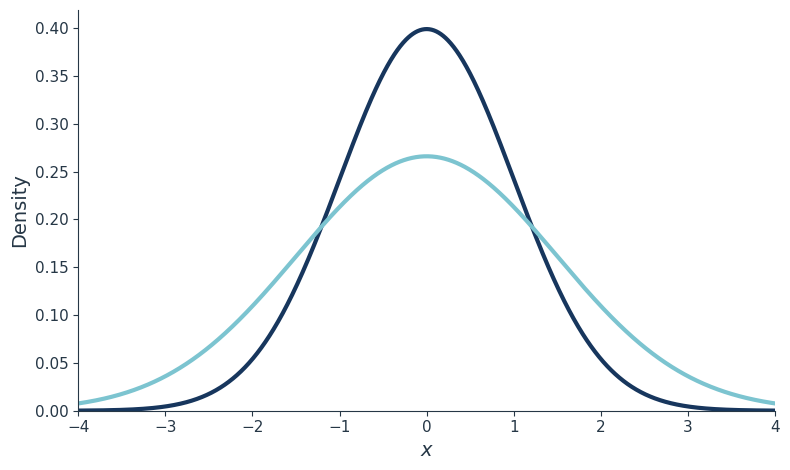

In [2]:
# Plot 1: same mean, different variances
# mu_1 = mu_2 = 0, but sigma_1^2 != sigma_2^2

compare_normal_distributions(
    distributions=[
        (0, 1.0, NAVY),
        (0, 1.5, LIGHT_BLUE),
    ],
    filename="normal_same_mean_different_variance.png",
)


Saved: C:\GitHub\STA1_26\04_Continuous_Distributions_in_Practice\session_material\normal_different_means_same_variance.png


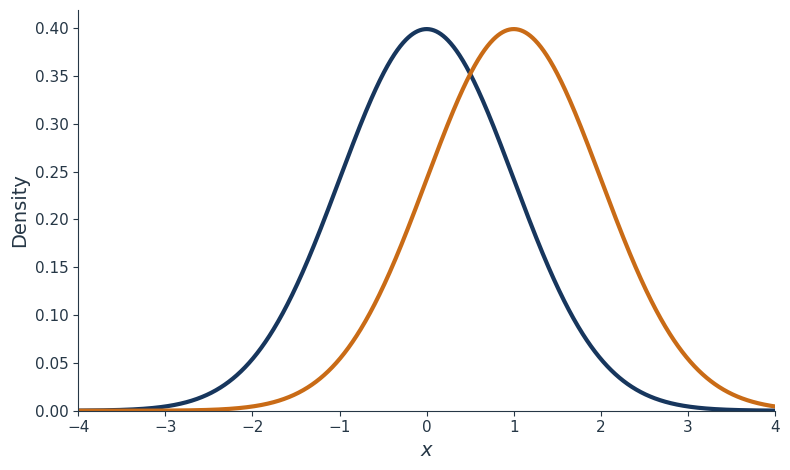

In [3]:
# Plot 2: different means, same variance
# mu_1 != mu_2, but sigma_1^2 = sigma_2^2

compare_normal_distributions(
    distributions=[
        (0, 1.0, NAVY),
        (1, 1.0, ORANGE),
    ],
    filename="normal_different_means_same_variance.png",
)


Saved: C:\GitHub\STA1_26\04_Continuous_Distributions_in_Practice\session_material\normal_different_means_and_variances.png


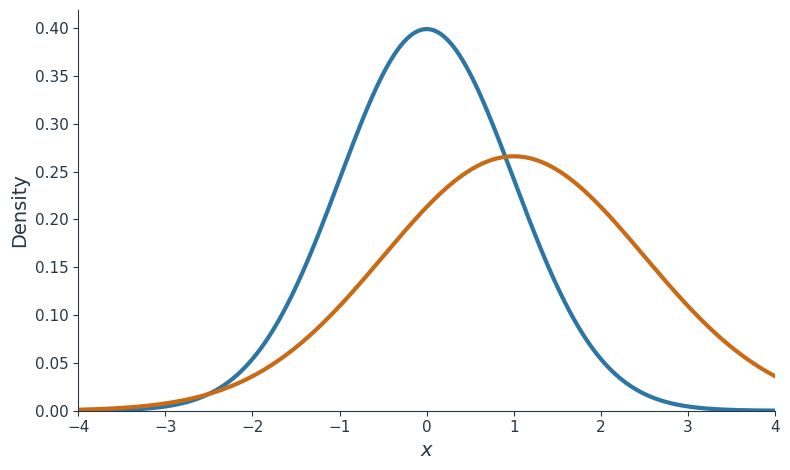

In [4]:
# Plot 3: different means and different variances
# mu_1 != mu_2 and sigma_1^2 != sigma_2^2

compare_normal_distributions(
    distributions=[
        (0, 1.0, BLUE),
        (1, 1.5, ORANGE),
    ],
    filename="normal_different_means_and_variances.png",
)
